##  Jour 12 — Initialisation des Poids

###  Concept Théorique

L'initialisation des poids est **cruciale** :
- **Trop petits** → vanishing gradient (les gradients disparaissent)
- **Trop grands** → exploding gradient (les gradients explosent)

###  Méthodes d'Initialisation

**Xavier/Glorot** (pour sigmoid, tanh) :
$$W \sim \mathcal{N}\left(0, \sqrt{\frac{2}{n_{\text{in}} + n_{\text{out}}}}\right)$$

**He** (pour ReLU) :
$$W \sim \mathcal{N}\left(0, \sqrt{\frac{2}{n_{\text{in}}}}\right)$$

###  Implémentation


=== Effet de l'Initialisation ===



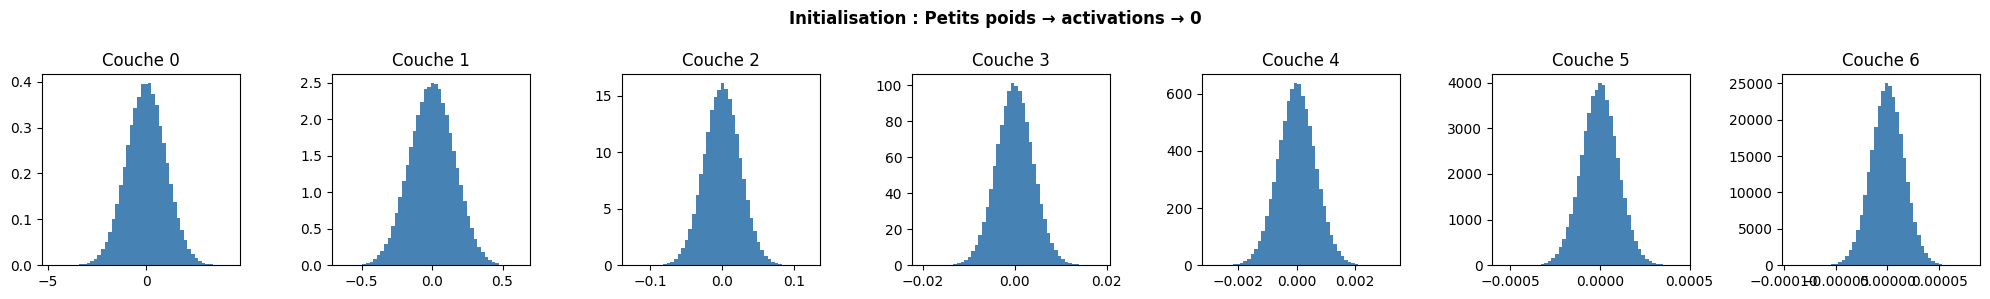

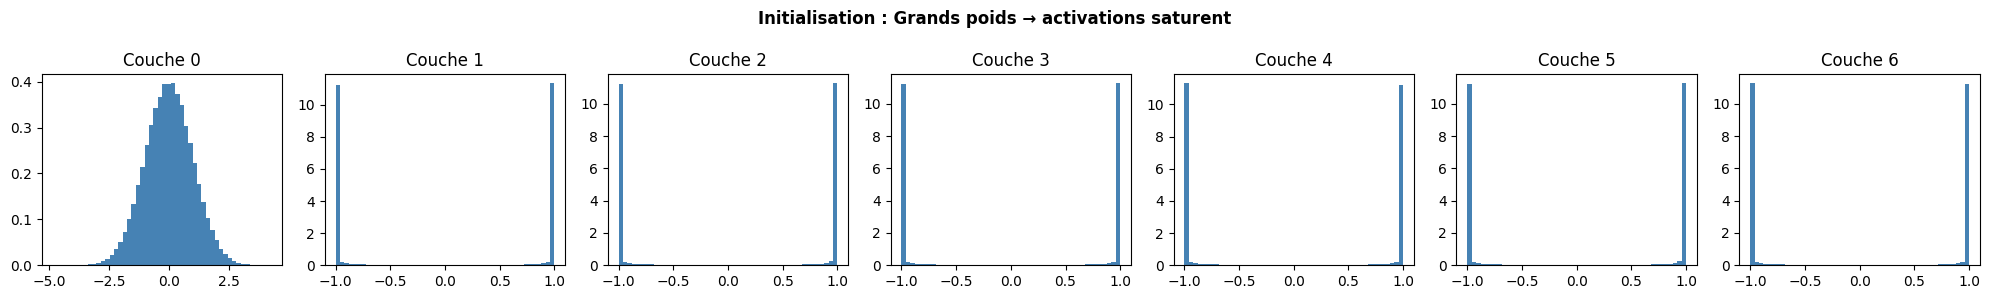

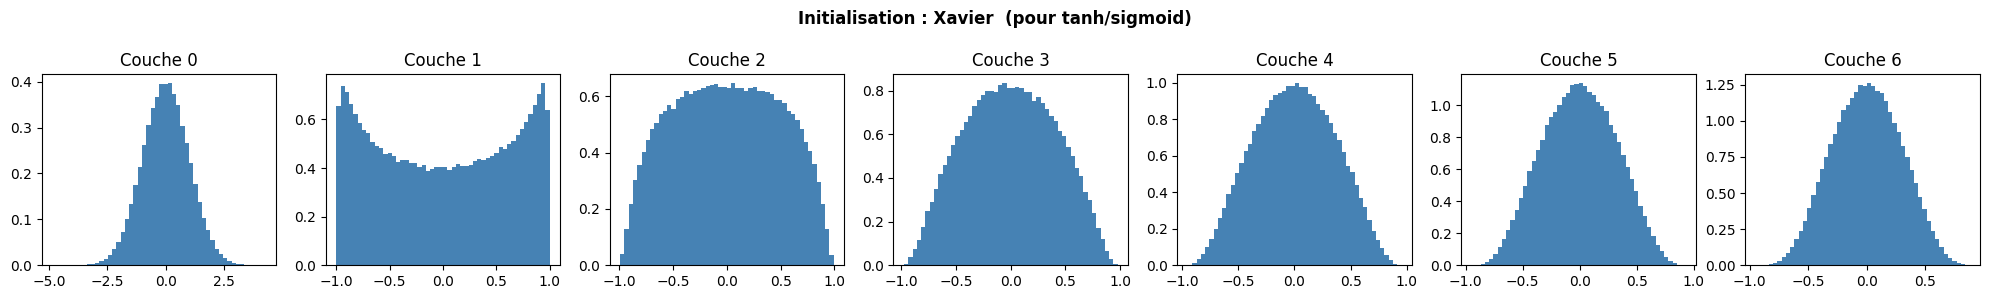

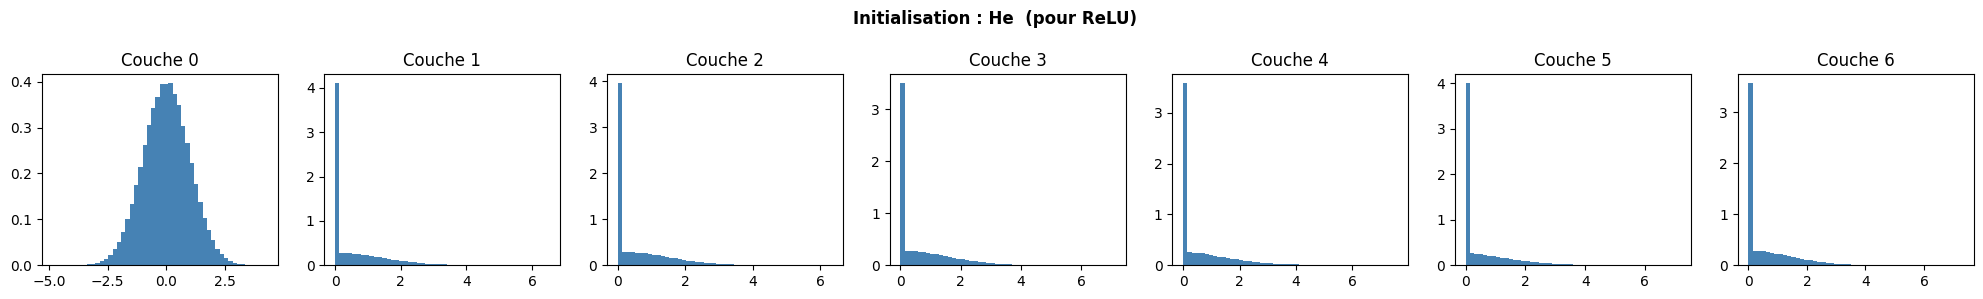

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# JOUR 12 : Initialisation des Poids
# ============================================================

def visualize_activations(init_method, title):
    np.random.seed(0)
    n_layers, n_neurons = 6, 256
    x = np.random.randn(1000, n_neurons)
    activations = [x]
    
    for i in range(n_layers):
        if init_method == 'small_random':
            W = np.random.randn(n_neurons, n_neurons) * 0.01
        elif init_method == 'large_random':
            W = np.random.randn(n_neurons, n_neurons) * 1.0
        elif init_method == 'xavier':
            W = np.random.randn(n_neurons, n_neurons) * np.sqrt(1.0 / n_neurons)
        elif init_method == 'he':
            W = np.random.randn(n_neurons, n_neurons) * np.sqrt(2.0 / n_neurons)
        
        x = x @ W
        x = np.tanh(x) if init_method != 'he' else np.maximum(0, x)
        activations.append(x)
    
    fig, axes = plt.subplots(1, n_layers + 1, figsize=(20, 3))
    fig.suptitle(f"Initialisation : {title}", fontweight='bold')
    for i, act in enumerate(activations):
        axes[i].hist(act.ravel(), bins=50, density=True, color='steelblue')
        axes[i].set_title(f"Couche {i}")
    plt.tight_layout()
    plt.show()

print("=== Effet de l'Initialisation ===\n")
visualize_activations('small_random', 'Petits poids → activations → 0')
visualize_activations('large_random', 'Grands poids → activations saturent')
visualize_activations('xavier', 'Xavier  (pour tanh/sigmoid)')
visualize_activations('he', 'He  (pour ReLU)')